## Setup

In [16]:
import os
import warnings
import numpy as np
import pandas as pd
import pickle
from numbers import Number
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from esda.moran import Moran
from scipy.stats import spearmanr, norm
from scipy.spatial import distance_matrix
from libpysal.weights import full2W, Queen, KNN
from spreg import ML_LagFE, ML_LagRE, ML_ErrorRE, ML_ErrorFE, PooledOLS, PanelFE, PanelRE
from spreg.sputils import spmultiplier, _sp_effects
import spreg.diagnostics as diagnostics

# warnings.simplefilter("ignore")

In [2]:
base_dir = './'
data_dir = os.path.join(base_dir, 'data')
results_dir = os.path.join(base_dir, 'results')

In [3]:
df = pd.read_csv(os.path.join(data_dir, 'df.csv'))
df = df.sort_values(by=["year", "name"])
shape_data = gpd.read_file(os.path.join(data_dir, "..", "raw_data", "irradiance", "LAD_MAY_2024_UK_BFE.shp"))\
                .set_crs("EPSG:27700").to_crs("EPSG:4326")

In [97]:
def get_stars(p, p001="***", p01="**", p05="*", p10="+", p_=""):
    if not isinstance(p, Number):
        return p
    if p < 0.001:
        return p001
    if p < 0.010:
        return p01
    if p < 0.050:
        return p05
    if p < 0.100:
        return p10
    return p_

def get_results(r, w=None):
    def get_sp_effects(r, w):
        sp_ef = _sp_effects(r, r.output, spmultiplier(w, r.rho, method="simple"), r.slx_lags, "All")
        sp_ef = pd.DataFrame(np.asarray(sp_ef).tolist()).T
        sp_ef.columns = ['total', 'direct', 'indirect']
        sp_ef.index = r.name_x
        return sp_ef.map(lambda x: x[0])
    
    def get_vif(r):
        try:
            vif = diagnostics.vif(r)
            vif = pd.DataFrame(np.asarray(vif)[:,0])
            vif.index = r.name_x[:len(vif)]
            vif.columns = ['vif']
        except:
            return None
        return vif

    def combine_tests(r):
        if hasattr(r, "bsk"):
            if hasattr(r, "hausman_stat"):
                return pd.concat([r.bsk, pd.DataFrame.from_dict({"Test": "Hausman Specification Test", 
                                        "Statistic": r.hausman_stat, 
                                        "df": r.hausman_df, 
                                        "p-value": r.hausman_p}, orient='index').T], axis=0)\
                                            .reset_index(drop=True)
            return r.bsk
        return None
    

    df_const = 1 if "CONSTANT" in set(r.output["var_names"]) else 0
    df_resid = r.df_resid if hasattr(r, "df_resid") else r.n - r.k
    df_model = r.n - df_resid - df_const  
    return {'r2': r.pr2 if hasattr(r, "pr2") else r.r2,
 'llr': r.logll,
 'aic': r.aic,
 'schwarz': r.schwarz,
 'f_stat': r.f_stat[0] if hasattr(r, "f_stat") else None,
 'f_stat_p': r.f_stat[1] if hasattr(r, "f_stat") else None,
 'f_df_resid': df_resid,
 'f_df_model': df_model,
 
 'n_obs': r.n,
 'n_params': r.k,
 'n_const': df_const,

 'rho': r.rho if hasattr(r, "rho") else None,
 'sigma2': np.asarray(r.sig2).reshape(1)[0] if hasattr(r, "sig2") else None,
 'sigma2_epsilon': r.sigma2_epsilon if hasattr(r, "sigma2_epsilon") else None,
 'sigma2_mu': r.sigma2_mu if hasattr(r, "sigma2_mu") else None,
 'theta': r.theta if hasattr(r, "theta") else None,
 
 'vif': get_vif(r),
 'tests': combine_tests(r), # tests
 'outputs': r.output, # all params
 'effects': get_sp_effects(r, w) if w is not None and hasattr(r, "rho") else None,
}

In [5]:
model_results = {}
results_file = os.path.join(results_dir, "model_results.pickle")
if os.path.exists(results_file):
    with open(results_file, "rb") as f:
        model_results = pickle.load(f)

In [ ]:
cache_weights = {}
weights_file = os.path.join(results_dir, "cache_weights.pickle")
if os.path.exists(weights_file):
    with open(weights_file, "rb") as f:
        cache_weights = pickle.load(f)

In [6]:
n_models = ["ML_LagFE", "ML_LagRE", "ML_ErrorRE", "ML_ErrorFE", "PooledOLS", "PanelFE", "PanelRE", ]
w_methods = ["inverse_distance", "k_nearest", "queen"]
y_vars = ["log_pv_cap", "log_pv_inst", "log_pv_cap_per_inst"]
x_vars = {
    "densities": ["pdensity", "hdensity", "fdensity", "adensity"],
    "capacities": ["log_gdp_cap", "log_fcapacity", "log_hcapacity", "log_acapacity"],
    "baseline": ["log_income", "log_hholds", "irradiance"],  # 'log_house_price',
}

In [102]:
def get_full_table(y='log_pv_cap', x_vars='baseline'):
    _results = []
    i = model_results[y]
    for xvars in i.keys():
        if xvars == x_vars:
            for nmodels in i[xvars].keys():
                for wmethods in i[xvars][nmodels].keys():
                    for k in i[xvars][nmodels][wmethods].keys():
                        key = f"{xvars}-{nmodels}-{wmethods}-{k}"
                        _r = i[xvars][nmodels][wmethods][k]
                        if _r:
                            # print(key)
                            _r = get_results(_r)
                            # _r['model'] = key
                            _o = _r['outputs']
                            _o.index = _o['var_names']
                            _o[0] = _o.apply(lambda x: f"{x['coefficients']:.3f}{get_stars(x['prob'])}", axis=1)
                            _r = pd.DataFrame.from_dict([_r]).T
                            _r = pd.concat([_r, _o[[0]]], ignore_index=False)
                            _r.columns = [key]
                            _results.append(_r)
    _results = pd.concat(_results, axis=1)
    return _results

get_full_table()

,"baseline-ML_LagFE-inverse_distance-Running ML_LagFE:inverse_distance for log_pv_cap ~ (baseline): ['log_income', 'log_hholds']","baseline-ML_LagFE-k_nearest-Running ML_LagFE:k_nearest for log_pv_cap ~ (baseline): ['log_income', 'log_hholds']","baseline-ML_LagFE-queen-Running ML_LagFE:queen for log_pv_cap ~ (baseline): ['log_income', 'log_hholds']","baseline-ML_LagRE-inverse_distance-Running ML_LagRE:inverse_distance for log_pv_cap ~ (baseline): ['log_income', 'log_hholds', 'irradiance']","baseline-ML_LagRE-k_nearest-Running ML_LagRE:k_nearest for log_pv_cap ~ (baseline): ['log_income', 'log_hholds', 'irradiance']","baseline-ML_LagRE-queen-Running ML_LagRE:queen for log_pv_cap ~ (baseline): ['log_income', 'log_hholds', 'irradiance']","baseline-ML_ErrorRE-inverse_distance-Running ML_ErrorRE:inverse_distance for log_pv_cap ~ (baseline): ['log_income', 'log_hholds', 'irradiance']","baseline-ML_ErrorRE-queen-Running ML_ErrorRE:queen for log_pv_cap ~ (baseline): ['log_income', 'log_hholds', 'irradiance']","baseline-ML_ErrorFE-inverse_distance-Running ML_ErrorFE:inverse_distance for log_pv_cap ~ (baseline): ['log_income', 'log_hholds']","baseline-ML_ErrorFE-k_nearest-Running ML_ErrorFE:k_nearest for log_pv_cap ~ (baseline): ['log_income', 'log_hholds']","baseline-ML_ErrorFE-queen-Running ML_ErrorFE:queen for log_pv_cap ~ (baseline): ['log_income', 'log_hholds']","baseline-PooledOLS-inverse_distance-Running PooledOLS:inverse_distance for log_pv_cap ~ (baseline): ['log_income', 'log_hholds', 'irradiance']","baseline-PooledOLS-k_nearest-Running PooledOLS:k_nearest for log_pv_cap ~ (baseline): ['log_income', 'log_hholds', 'irradiance']","baseline-PooledOLS-queen-Running PooledOLS:queen for log_pv_cap ~ (baseline): ['log_income', 'log_hholds', 'irradiance']","baseline-PanelFE-inverse_distance-Running PanelFE:inverse_distance for log_pv_cap ~ (baseline): ['log_income', 'log_hholds']","baseline-PanelFE-k_nearest-Running PanelFE:k_nearest for log_pv_cap ~ (baseline): ['log_income', 'log_hholds']","baseline-PanelFE-queen-Running PanelFE:queen for log_pv_cap ~ (baseline): ['log_income', 'log_hholds']","baseline-PanelRE-inverse_distance-Running PanelRE:inverse_distance for log_pv_cap ~ (baseline): ['log_income', 'log_hholds', 'irradiance']","baseline-PanelRE-k_nearest-Running PanelRE:k_nearest for log_pv_cap ~ (baseline): ['log_income', 'log_hholds', 'irradiance']","baseline-PanelRE-queen-Running PanelRE:queen for log_pv_cap ~ (baseline): ['log_income', 'log_hholds', 'irradiance']"
r2,0.79382,0.765459,0.75421,0.779759,0.746157,0.732675,0.25801,0.118195,0.548393,0.730239,0.741393,0.258382,0.258382,0.258382,0.047466,0.047466,0.047466,0.069456,0.069456,0.069456
llr,2193.659089,2001.178455,1943.41131,1189.814761,960.349731,885.767369,1234.000223,917.022827,2233.6161,1994.053762,1934.416447,-1815.562601,-1815.562601,-1815.562601,-12082.642446,-12082.642446,-12082.642446,-2497.776005,-2497.776005,-2497.776005
aic,-4381.318179,-3996.356911,-3880.822619,-2369.629522,-1910.699462,-1761.534739,-2460.000446,-1826.045653,-4463.2322,-3984.107524,-3864.832895,3639.125202,3639.125202,3639.125202,24169.284893,24169.284893,24169.284893,5003.552011,5003.552011,5003.552011
schwarz,-4363.438255,-3978.476987,-3862.942696,-2339.885829,-1880.955769,-1731.791046,-2436.205492,-1802.2507,-4451.312251,-3972.187575,-3852.912946,3662.920156,3662.920156,3662.920156,24181.204842,24181.204842,24181.204842,5027.346965,5027.346965,5027.346965
f_stat,None,None,None,None,None,None,None,None,None,None,None,328.428288,328.428288,328.428288,2860.155947,2860.155947,2860.155947,481.681457,481.681457,481.681457
f_stat_p,None,None,None,None,None,None,None,None,None,None,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
f_df_resid,2861,2861,2861,2827,2827,2827,2828,2828,2862,2862,2862,2828,2828,2828,2506,2506,2506,2828,2828,2828
f_df_model,3,3,3,4,4,4,3,3,2,2,2,3,3,3,358,358,358,3,3,3
n_obs,2864,2864,2864,2832,2832,2832,2832,2832,2864,2864,2864,2832,2832,2832,2864,2864,2864,2832,2832,2832
n_par

In [40]:
i = model_results['log_pv_cap']["baseline"]["PooledOLS"]['queen'].copy()
r = next(iter(i.values()))
f = next(iter(i.keys()))

In [ ]:
w = cache_weights[f][0]

In [46]:
get_results(r)#, w)


{'r2': np.float64(0.2583821823056337),
 'llr': np.float64(-1815.5626012125804),
 'aic': np.float64(3639.1252024251608),
 'schwarz': np.float64(3662.920156244415),
 'f_stat': np.float64(328.4282884105204),
 'f_stat_p': np.float64(5.876323556664787e-183),
 'f_df_resid': 2828,
 'f_df_model': 3,
 'n_obs': 2832,
 'n_params': 4,
 'n_const': 1,
 'rho': None,
 'sigma2': np.float64(0.2113400861452715),
 'sigma2_epsilon': None,
 'sigma2_mu': None,
 'theta': None,
 'vif': None,
 'tests':                         Test    Statistic  df  p-value
 0       LM Marginal RE (LM1)    83.300664   1      0.0
 1  LM Marginal Spatial (LM2)     8.662705   1      0.0
 2             LM Joint (LMJ)  7014.043156   2      0.0,
 'outputs':     var_names coefficients   std_err    zt_stat      prob
 0    CONSTANT     1.827545  0.371875   4.914412  0.000001
 1  log_income    -0.741773  0.092872  -7.987003       0.0
 2  log_hholds     0.252649  0.009175  27.537372       0.0
 3  irradiance     0.001115  0.000097  11.51149

In [48]:
print(r.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: POOLED OLS PANEL
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :       queen
Dependent Variable  :  log_pv_cap                Number of Observations:        2832
Mean dependent var  :      1.1662                Number of Variables   :           4
S.D. dependent var  :      0.5335                Degrees of Freedom    :        2828
R-squared           :      0.2584
Adjusted R-squared  :      0.2576
Sum squared residual:      597.67                F-statistic           :    328.4283
Sigma-square        :       0.211                Prob(F-statistic)     :  5.876e-183
S.E. of regression  :       0.460                Log likelihood        :   -1815.563
Sigma-square ML     :       0.211                Akaike info criterion :    3639.125
S.E of regression ML:      0.4594                Schwarz criterion     :    3662.920

-----------------------

In [33]:
vif

,vif
CONSTANT,1.012119e-28
log_income,1.060512e+00
log_hholds,1.045976e+00
irradiance,1.014334e+00


In [30]:
vif

,0
CONSTANT,1.012119e-28
log_income,1.060512e+00
log_hholds,1.045976e+00
irradiance,1.014334e+00


In [ ]:

for i in range(len(r.name_x)-1):
        i += 1
        print("Variable             VIF      Tolerance")
        print("%20s    %12.4f   %12.4f\n" % (
        r.name_x[i], vif[i][0], vif[i][1]))

Variable             VIF      Tolerance
          log_income          1.0605         0.9429

Variable             VIF      Tolerance
          log_hholds          1.0460         0.9560

Variable             VIF      Tolerance
          irradiance          1.0143         0.9859

Variable             VIF      Tolerance


IndexError: list index out of range

['log_income', 'log_hholds', 'W_log_pv_cap']

In [4]:
def compute_weights(y, x, data, shape_data, method='inverse_distance', k=8, verbose=True):
    coords = shape_data[["LAT", "LONG"]].to_numpy()
    if method == 'inverse_distance':
            dist_mat = distance_matrix(coords, coords)
            np.fill_diagonal(dist_mat, np.inf)  # avoid division by zero
            w = 1 / dist_mat # Inverse distance weights
    elif method == 'queen':
            w = Queen.from_dataframe(shape_data, use_index=False)
            if len(w.islands) > 0:
                if verbose:
                    print(f"There are some islands in the data {method}({len(w.islands)}).")
                w_knn = KNN.from_array(coords, k=1)
                for i in w.islands: # use knn neighbors only for islands
                    w.neighbors[i] = w_knn.neighbors[i]
                    w.weights[i] = w_knn.weights[i]
            w.transform = "R"  
            w = w.full()[0]
    elif method == 'k_nearest':
            w = KNN.from_array(coords, k=k)
            if len(w.islands) > 0:
                if verbose:
                    print(f"There are some islands in the data {method}({len(w.islands)}).")
            w.transform = "R"  
            w = w.full()[0]
    w = pd.DataFrame(w, index=shape_data["LAD24CD"], columns=shape_data["LAD24CD"])
    d = data[['code', 'year'] + x + [y]].dropna() # NaNs filter
    if len(d) > 0:
        g_year = d.groupby('code').size().max()
        nonna_codes = []
        for code, group in d.groupby('code'):
            if (group['year'].nunique() < g_year) or (group.dropna().shape[0] < g_year):
                print(f"Code {code} has only {group['year'].nunique()} unique years.")
                pass
            else:
                nonna_codes.append(code)
        n_periods = f"{d['year'].nunique()} ({d['year'].min()}-{d['year'].max()})"
        codes = set(nonna_codes)
        w = w[[i for i in w.columns if i in codes]]
        n_units = w.columns.size
        w = w[[i in codes for i in w.index]]
        d = d[[i in codes for i in d.code]]
        w = full2W(np.asarray(w))
        w.transform = 'R'
        if verbose:
            print(f"Number of units: {n_units}, Number of periods: {n_periods}, Method: {method}")
        Y = d[y].values.reshape(-1, 1)
        X = d[x].values
        return w, X, Y
    else:
        if verbose:
            print("No valid data after dropping NaNs.")
        return None, None, None

def get_stars(p, p001="***", p01="**", p05="*", p10="+", p_=""):
    if not isinstance(p, Number):
        return p
    if p < 0.001:
        return p001
    if p < 0.010:
        return p01
    if p < 0.050:
        return p05
    if p < 0.100:
        return p10
    return p_

def average_correlations(r, n, alpha=0.05, method="two-tailed"):
    """
    r : list/array of correlations
    n : list/array of sample sizes
    """
    r = np.array(r, dtype=float)
    n = np.array(n, dtype=float)

    z = np.arctanh(r)  # 1) Fisher z-transform
    w = n - 3  # 2) Weights (inverse variance)
    z_bar = np.sum(w * z) / np.sum(w)  # 3) Pooled effect (weighted mean z)
    se = 1 / np.sqrt(np.sum(w))  # 4) Standard error of pooled effect
    z = z_bar / se  # 5) Test statistic
    p = 1 - norm.cdf(np.abs(z))  # 6) Two-tailed p-value
    p = p * 2 if method == "two-tailed" else p
    r_bar = np.tanh(z_bar)  # 7) Convert back to correlation
    # 8) CI in z-space, then back-transform
    # z-critical = stats.norm.ppf(1 - alpha) (use alpha = alpha/2 for two-sided)
    a = alpha / 2 if method == "two-tailed" else alpha
    z_crit = norm.ppf(1 - a)
    z_ci_low = z_bar - z_crit * se
    z_ci_high = z_bar + z_crit * se
    r_ci_low = np.tanh(z_ci_low)
    r_ci_high = np.tanh(z_ci_high)
    return {
        "r_mean": r_bar,
        "z_mean": z_bar,
        "se": se,
        "z": z,
        "p-value": p,
        "cil": r_ci_low,
        "cir": r_ci_high,
    }


def average_morans_i(i, i_var, method="two-tailed"):
    """
    I: array of Moran's I values
    var_I: array of variances of Moran's I
    """
    i = np.array(i, dtype=float)
    var_i = np.array(i_var, dtype=float)
    w = 1 / var_i  # weights = inverse variance
    i_bar = np.sum(w * i) / np.sum(w)  # weighted mean
    se = np.sqrt(1 / np.sum(w))  # standard error
    z = i_bar / se  # test statistic
    p = 1 - norm.cdf(np.abs(z))  # p-value (two-tailed)
    p = p * 2 if method == "two-tailed" else p
    return {
        "i_mean": i_bar,
        "z": z,
        "se": se,
        "p-value": p,
    }

## Temporal and spatial dynamics

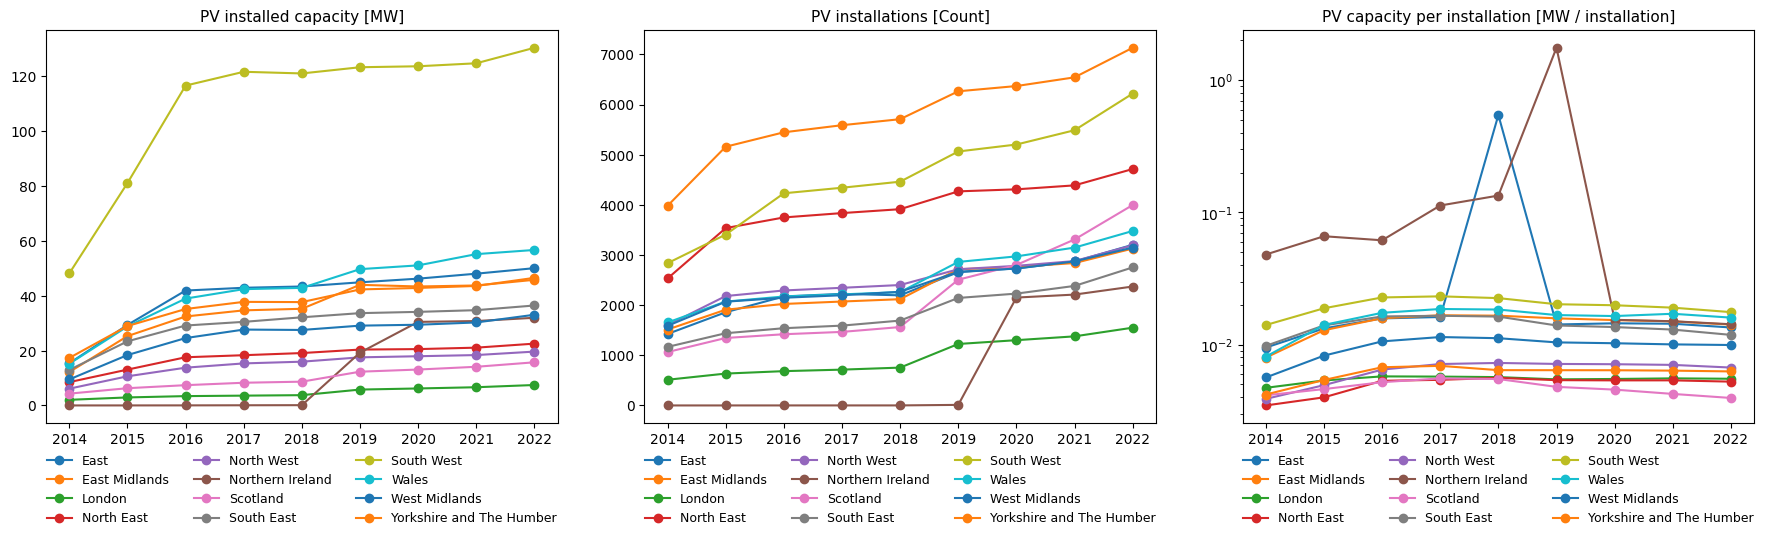

In [5]:
labels = {"log_pv_cap": "PV installed capacity [MW]",
        "log_pv_inst": "PV installations [Count]",
        "pv_cap_per_inst": "PV capacity per installation [MW / installation]",
        }

fig = plt.figure(figsize=(6.0 * 3, 5.5))
ax_left = fig.add_subplot(1, 3, 1)
d = df.copy()
d = d[['year', 'pv_cap', 'region']].groupby(['year', 'region']).mean().reset_index().pivot(index='year', columns='region', values='pv_cap')
d = d.rename(columns=labels)
d.plot(ax=ax_left, marker='o',)
ax_left.set_title(labels['log_pv_cap'], fontsize=11)
ax_left.set_xlabel(None)
ax_left.set_ylabel(None, labelpad=-5)
ax_left.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
               fontsize=9, frameon=False, ncols=3)

ax_middle = fig.add_subplot(1, 3, 2)
d = df.copy()
d = d[['year', 'pv_inst', 'region']].groupby(['year', 'region']).mean().reset_index().pivot(index='year', columns='region', values='pv_inst')
d = d.rename(columns=labels)
d.plot(ax=ax_middle, marker='o',)
ax_middle.set_title(labels['log_pv_inst'], fontsize=11)
ax_middle.set_xlabel(None)
ax_middle.set_ylabel(None, labelpad=-5)
ax_middle.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 fontsize=9, frameon=False, ncols=3)

ax_right = fig.add_subplot(1, 3, 3)
d = df.copy()
d = d[['year', 'pv_cap_per_inst', 'region']].groupby(['year', 'region']).mean().reset_index().pivot(index='year', columns='region', values='pv_cap_per_inst')
d = d.rename(columns=labels)
d.plot(ax=ax_right, marker='o', logy=True)
ax_right.set_title(labels['pv_cap_per_inst'], fontsize=11)
ax_right.set_xlabel(None)
ax_right.set_ylabel(None, labelpad=-5)
ax_right.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 fontsize=9, frameon=False, ncols=3)  

fig.subplots_adjust(wspace=0.001)
fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig_dyn.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format="pdf",
    )

## Correlations

In [6]:
vars = ["log_gdp_cap",
        "log_income", 
        "log_earnings", 
        "log_population", 
        "log_hholds", 
        "log_firms",
        #"log_employees", 
        "log_house_price",
        "pdensity", 
        "hdensity", 
        "fdensity",
        "adensity",
        #"gini_assets",
        #"gini_earnings",
        #"gini_employees",
        "log_fcapacity",
        "log_hcapacity",
        "log_acapacity",
        ]
corr_results = [] 
for k in ['log_pv_cap', 'log_pv_inst', 'pv_cap_per_inst']:
    d = {}
    for v in vars:
        df_v = df[[k, v, 'year']].dropna()
        if len(df_v) > 0:
            r, n = [], []
            for y in df_v["year"].unique():
                df_y = df_v[df_v["year"] == y].copy()
                if len(df_y) > 0 and df_y[k].notna().sum() > 0:
                    r_v, p = spearmanr(df_y[k], df_y[v], nan_policy='omit')
                    r.append(r_v)
                    n.append(len(df_y))
            r_a = average_correlations(r, n)
            d[v] = f"{r_a["r_mean"]:.2f}" + "^{" + f"{get_stars(r_a['p-value'])}" + "}"
    corr_results.append({k: d})

corr_results = pd.concat([pd.concat([pd.DataFrame.from_dict(v, orient='index', columns=[k]) 
                      for k, v in i.items()], axis=0) for i in corr_results], axis=1)
# corr_results.to_csv(os.path.join(results_dir, 'avg_corr_results.csv'), index=True)
corr_results

,log_pv_cap,log_pv_inst,pv_cap_per_inst
log_gdp_cap,-0.09^{***},-0.09^{***},-0.02^{}
log_income,-0.07^{***},-0.22^{***},0.13^{***}
log_earnings,-0.25^{***},-0.34^{***},-0.03^{}
log_population,0.14^{***},0.39^{***},-0.13^{***}
log_hholds,0.26^{***},0.51^{***},-0.14^{***}
log_firms,0.06^{***},0.23^{***},-0.07^{***}
log_house_price,-0.25^{***},-0.40^{***},0.06^{**}
pdensity,-0.47^{***},-0.27^{***},-0.50^{***}
hdensity,-0.43^{***},-0.22^{***},-0.50^{***}
fdensity,-0.45^{***},-0.27^{***},-0.45^{***}


In [7]:
pv_cap_corr_results = [] 
for y in df["year"].unique():
    df_y = df[df["year"] == y].copy()
    if len(df_y) > 0 and df_y['log_pv_cap'].notna().sum() > 0:
        d = {'year': y}
        for v in vars:
            r_v, p = spearmanr(df_y['log_pv_cap'], df_y[v], nan_policy='omit')
            d[f'r_{v}'] = r_v
            d[f'p_{v}'] = p
        pv_cap_corr_results.append(d)
pv_cap_corr_results = pd.DataFrame(pv_cap_corr_results)

pv_inst_corr_results = [] 
for y in df["year"].unique():
    df_y = df[df["year"] == y].copy()
    if len(df_y) > 0 and df_y['log_pv_inst'].notna().sum() > 0:
        d = {'year': y}
        for v in vars:
            r_v, p = spearmanr(df_y['log_pv_inst'], df_y[v], nan_policy='omit')
            d[f'r_{v}'] = r_v
            d[f'p_{v}'] = p
        pv_inst_corr_results.append(d)
pv_inst_corr_results = pd.DataFrame(pv_inst_corr_results)

pv_cap_per_inst_corr_results = [] 
for y in df["year"].unique():
    df_y = df[df["year"] == y].copy()
    if len(df_y) > 0 and df_y['log_pv_cap_per_inst'].notna().sum() > 0:
        d = {'year': y}
        for v in vars:
            r_v, p = spearmanr(df_y['log_pv_cap_per_inst'], df_y[v], nan_policy='omit')
            d[f'r_{v}'] = r_v
            d[f'p_{v}'] = p
        pv_cap_per_inst_corr_results.append(d)
pv_cap_per_inst_corr_results = pd.DataFrame(pv_cap_per_inst_corr_results)

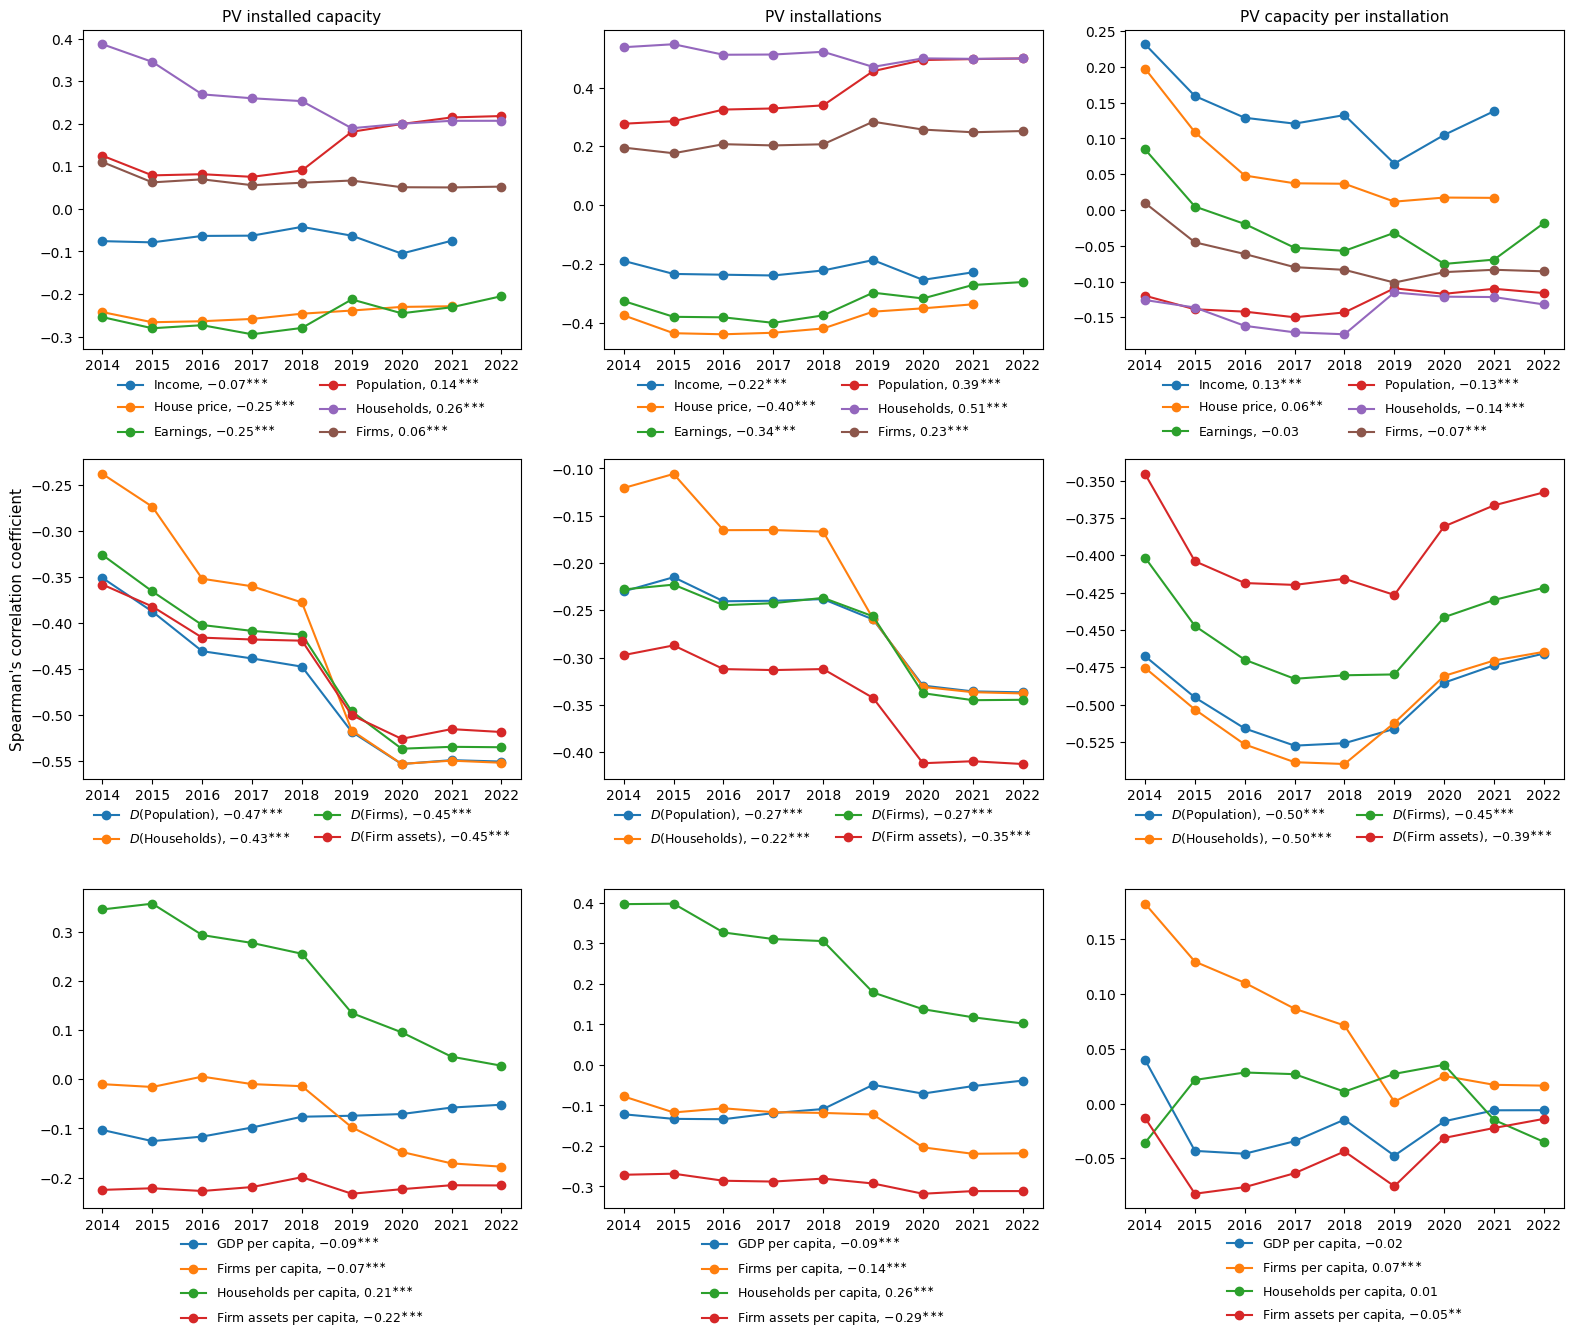

In [9]:
labels = {#"r_log_gdp_cap": "GDP per capita",
        "r_log_income": "Income", 
        "r_log_earnings": "Earnings", 
        
        "r_log_house_price": "House price",
        "r_log_population": "Population", 
        "r_log_hholds": "Households",
        "r_log_firms": "Firms",
        #"r_log_employees": "Employees", 

        "r_pdensity": "$D$(Population)", 
        "r_hdensity": "$D$(Households)", 
        "r_fdensity": "$D$(Firms)",
        "r_adensity": "$D$(Firm assets)",

        "r_log_gdp_cap": "GDP per capita",
        "r_log_fcapacity": "Firms per capita",
        "r_log_hcapacity": "Households per capita",
        "r_log_acapacity": "Firm assets per capita",

        "r_gini_earnings": "$G$(Earnings)",
        "r_gini_assets": "$G$(Firm assets)",
        "r_gini_employees": "$G$(Employees)",

        "log_pv_cap": "PV installed capacity",
        "log_pv_inst": "PV installations",
        "pv_cap_per_inst": "PV capacity per installation"}

fig = plt.figure(figsize=(5.3 * 3, 4.5 * 3))

vars1 = [#"log_gdp_cap",
        "log_income", 
        "log_house_price",
        "log_earnings", 
        "log_population", 
        "log_hholds", 
        #"log_employees", 
        "log_firms",
        #"pdensity", 
        #"hdensity", 
        #"fdensity",
        #"adensity",
        #"gini_assets",
        #"gini_earnings",
        #"gini_employees",
        ]

ax_left = fig.add_subplot(3, 3, 1)
d = pv_cap_corr_results.copy()
d = d[['year'] + [c for v in vars1 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['log_pv_cap']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_left, marker='o',)
ax_left.set_title(labels['log_pv_cap'], fontsize=11)
ax_left.set_xlabel(None)
#ax_left.set_ylabel("Spearman's correlation coefficient", fontsize=11)
ax_left.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
               ncol=2, fontsize=9, frameon=False)

ax_middle = fig.add_subplot(3, 3, 2)
d = pv_inst_corr_results.copy()
d = d[['year'] + [c for v in vars1 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['log_pv_inst']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_middle, marker='o',)
ax_middle.set_title(labels['log_pv_inst'], fontsize=11)
ax_middle.set_xlabel(None)
ax_middle.set_ylabel("", labelpad=-5)
ax_middle.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 ncol=2, fontsize=9, frameon=False)

ax_right = fig.add_subplot(3, 3, 3)
d = pv_cap_per_inst_corr_results.copy()
d = d[['year'] + [c for v in vars1 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['pv_cap_per_inst']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_right, marker='o',)
ax_right.set_title(labels['pv_cap_per_inst'], fontsize=11)
ax_right.set_xlabel(None)
ax_right.set_ylabel("", labelpad=-5)
ax_right.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 ncol=2, fontsize=9, frameon=False)

vars2 = [#"log_gdp_cap",
        #"log_income", 
        #"log_earnings", 
        #"log_population", 
        #"log_hholds", 
        #"log_employees", 
        "pdensity", 
        "hdensity", 
        "fdensity",
        "adensity",
        #"gini_assets",
        #"gini_earnings",
        #"gini_employees",
        ]

ax_left = fig.add_subplot(3, 3, 4)
d = pv_cap_corr_results.copy()
d = d[['year'] + [c for v in vars2 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['log_pv_cap']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_left, marker='o',)
#ax_left.set_title(labels['log_pv_cap'], fontsize=11)
ax_left.set_xlabel(None)
ax_left.set_ylabel("Spearman's correlation coefficient", fontsize=11)
ax_left.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
               ncol=2, fontsize=9, frameon=False)

ax_middle = fig.add_subplot(3, 3, 5)
d = pv_inst_corr_results.copy()
d = d[['year'] + [c for v in vars2 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['log_pv_inst']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_middle, marker='o',)
#ax_middle.set_title(labels['log_pv_inst'], fontsize=11)
ax_middle.set_xlabel(None)
ax_middle.set_ylabel("", labelpad=-5)
ax_middle.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 ncol=2, fontsize=9, frameon=False)

ax_right = fig.add_subplot(3, 3, 6)
d = pv_cap_per_inst_corr_results.copy()
d = d[['year'] + [c for v in vars2 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['pv_cap_per_inst']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_right, marker='o',)
#ax_right.set_title(labels['pv_cap_per_inst'], fontsize=11)
ax_right.set_xlabel(None)
ax_right.set_ylabel("", labelpad=-5)
ax_right.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 ncol=2, fontsize=9, frameon=False)


vars3 = [#"log_gdp_cap",
        #"log_income", 
        #"log_earnings", 
        #"log_population", 
        #"log_hholds", 
        #"log_employees", 
        #"pdensity", 
        #"hdensity", 
        #"fdensity",
        #"adensity",
        #"gini_assets",
        #"gini_earnings",
        #"gini_employees",

        "log_gdp_cap",
        "log_fcapacity",
        "log_hcapacity",
        "log_acapacity",
        ]

ax_left = fig.add_subplot(3, 3, 7)
d = pv_cap_corr_results.copy()
d = d[['year'] + [c for v in vars3 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['log_pv_cap']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_left, marker='o',)
#ax_left.set_title(labels['log_pv_cap'], fontsize=11)
ax_left.set_xlabel(None)
#ax_left.set_ylabel("Spearman's correlation coefficient", fontsize=11)
ax_left.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
               ncol=1, fontsize=9, frameon=False)

ax_middle = fig.add_subplot(3, 3, 8)
d = pv_inst_corr_results.copy()
d = d[['year'] + [c for v in vars3 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['log_pv_inst']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_middle, marker='o',)
#ax_middle.set_title(labels['log_pv_inst'], fontsize=11)
ax_middle.set_xlabel(None)
ax_middle.set_ylabel("", labelpad=-5)
ax_middle.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 ncol=1, fontsize=9, frameon=False)

ax_right = fig.add_subplot(3, 3, 9)
d = pv_cap_per_inst_corr_results.copy()
d = d[['year'] + [c for v in vars3 for c in d.columns if v in str(c)]]
d = d[['year'] + [i for i in d.columns if i.startswith('r_')]]
labels_ = {k: f"{v}, ${r['pv_cap_per_inst']}$".replace("*", r"{\ast}") for k, v in labels.items() for i, r in corr_results.iterrows() if i == k[2:]}
d = d.rename(columns=labels_).set_index('year')
d.plot(ax=ax_right, marker='o',)
#ax_right.set_title(labels['pv_cap_per_inst'], fontsize=11)
ax_right.set_xlabel(None)
ax_right.set_ylabel("", labelpad=-5)
ax_right.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 ncol=1, fontsize=9, frameon=False)


fig.subplots_adjust(wspace=0.001)
fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig_corr1.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format="pdf",
    )

In [10]:
vars = [ 
        "log_pv_cap",
        "log_pv_inst",
        "pv_cap_per_inst",

        #"log_gdp_cap",
        "log_house_price",
        "log_income", 
        "log_earnings", 
        "log_assets",

        "log_population", 
        "log_hholds", 
        "log_firms",
        #"log_employees", 

        "pdensity", 
        "hdensity", 
        "fdensity",
        "adensity",

        #"gini_earnings",
        #"gini_assets",
        #"gini_employees",
        "log_gdp_cap",
        "log_fcapacity",
        "log_hcapacity",
        "log_acapacity",
        ]
full_corr_results_r = {} 
full_corr_results_p = {} 
for v1 in vars:
    full_corr_results_r.setdefault(v1, {})
    full_corr_results_p.setdefault(v1, {})
    for v2 in vars:
        if v1 == v2:
            continue
        full_corr_results_r[v1].setdefault(v2, 0)
        full_corr_results_p[v1].setdefault(v2, 0)
        df_v = df[[v1, v2, 'year']].dropna()
        if len(df_v) > 0:
            r, n = [], []
            for y in df_v["year"].unique():
                df_y = df_v[df_v["year"] == y].copy()
                if len(df_y) > 0 and df_y[v1].notna().sum() > 0:
                    r_v, p = spearmanr(df_y[v1], df_y[v2], nan_policy='omit')
                    r.append(r_v)
                    n.append(len(df_y))
            r_a = average_correlations(r, n)
            full_corr_results_r[v1][v2] = r_a['r_mean'] # f"{r_a["r_mean"]:.2f}" + "^{" + f"{get_stars(r_a['p-value'])}" + "}"
            full_corr_results_p[v1][v2] = r_a['p-value'] 

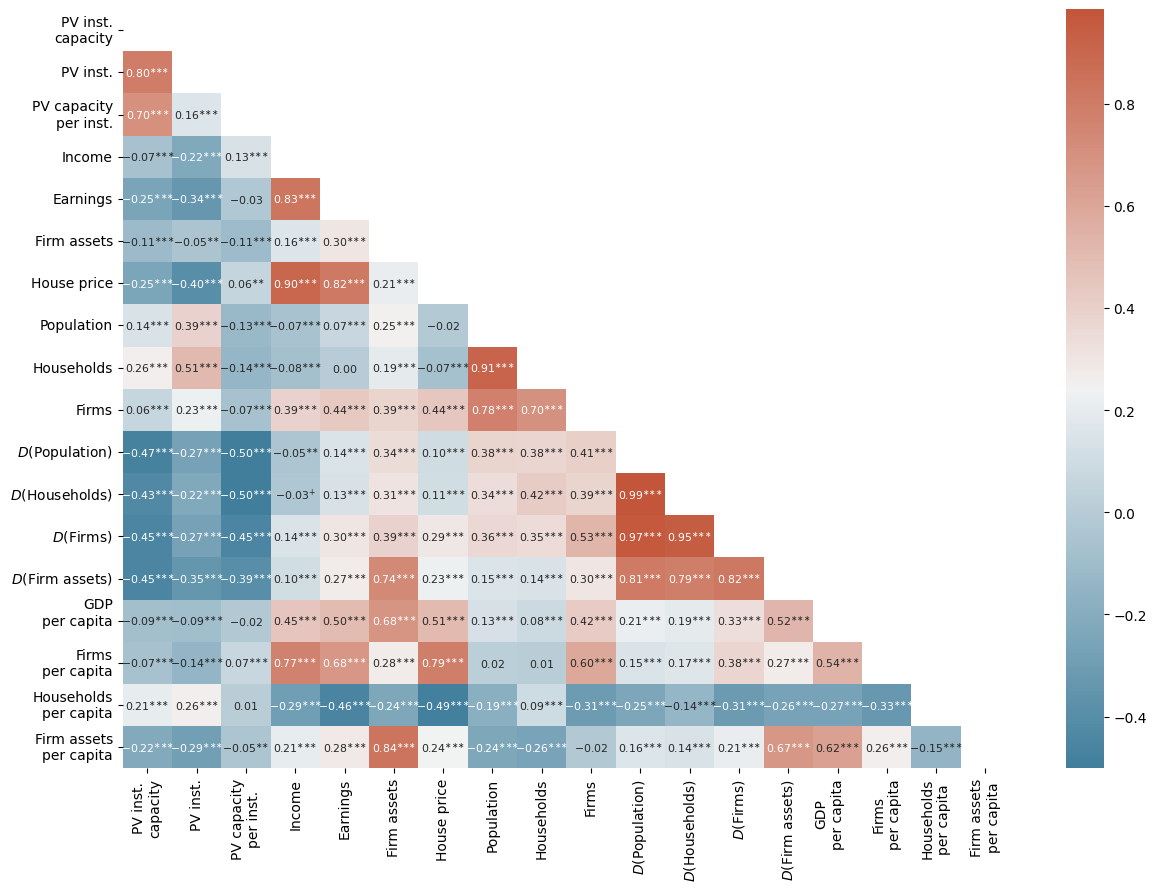

In [12]:
labels = {
    
        "log_pv_cap": "PV inst.\ncapacity",
        "log_pv_inst": "PV inst.",
        "pv_cap_per_inst": "PV capacity\nper inst.",
    
        #"log_gdp_cap": "GDP\nper capita\n",
        "log_income": "Income", 
        "log_earnings": "Earnings", 
        "log_assets": "Firm assets", 
        "log_house_price": "House price",

        "log_population": "Population", 
        "log_hholds": "Households",
        "log_firms": "Firms",
        #"log_employees": "Employees", 
        
        "pdensity": "$D$(Population)", 
        "hdensity": "$D$(Households)", 
        "fdensity": "$D$(Firms)",
        "adensity": "$D$(Firm assets)",

        #"gini_earnings": "$G$(Earnings)",
        #"gini_assets": "$G$(Firm assets)",
        #"gini_employees": "$G$(Employees)",

        "log_gdp_cap": "GDP\nper capita\n",
        "log_fcapacity": "Firms\nper capita",
        "log_hcapacity": "Households\nper capita",
        "log_acapacity": "Firm assets\nper capita",
}

fig = plt.figure(figsize=(12.5, 9))
ax_left = fig.add_subplot()
c = pd.DataFrame(full_corr_results_r).copy()
c = c.reindex(index=labels.keys(), columns=labels.keys())
p = pd.DataFrame(full_corr_results_p).copy()
p = p.reindex(index=labels.keys(), columns=labels.keys())
a = c.copy().astype(str)
for i in a.keys():
    for j in a[i].keys():
        a.loc[i, j] = f"${c[i][j]:.2f}^{{{get_stars(p[i][j])}}}$".replace('*', r'{\ast}')
c = c.rename(columns=labels)
c.index = c.index.map(labels)
cmap = sns.diverging_palette(230, 20, n=256, as_cmap=True) #cmap="YlGnBu"
mask = np.triu(np.ones_like(c, dtype=bool))
ax_left = sns.heatmap(c, cmap=cmap, mask=mask, annot_kws={'va':'center', 'fontsize': 7.8}, fmt='', 
                 robust=False, ax=ax_left, cbar=True, annot=a)
fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig_corr2.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format="pdf",
    )

## Moran tests

In [6]:
# Global spatial autocorrelation (Moran’s I)
methods = ['inverse_distance', 'k_nearest', 'queen']

f = os.path.join(results_dir, 'moran_results.pickle')
if not os.path.exists(f):
    pv_cap_moran_results = [] 
    for y in df["year"].unique():
        df_y = df[df["year"] == y].copy()
        if len(df_y) > 0 and df_y['log_pv_cap'].notna().sum() > 0:
            d = {'year': y}
            for m in methods:
                w, X, Y = compute_weights('log_pv_cap', ['area'], data=df_y, shape_data=la, method=m, verbose=False)
                if w is not None:
                    mi = Moran(Y, w, transformation="R")
                    d[f'I_{m}'] = mi.I
                    d[f'p_{m}'] = mi.p_sim
                    d[f'VI_{m}'] = mi.VI_rand
            pv_cap_moran_results.append(d)
    pv_cap_moran_results = pd.DataFrame(pv_cap_moran_results)

    pv_inst_moran_results = []
    for y in df["year"].unique():
        df_y = df[df["year"] == y].copy()
        if len(df_y) > 0 and df_y['log_pv_inst'].notna().sum() > 0:
            d = {'year': y}
            for m in methods:
                w, X, Y = compute_weights('log_pv_inst', ['area'], data=df_y, 
                                        shape_data=la, method=m, verbose=False)
                if w is not None:
                    mi = Moran(Y, w, transformation="R")
                    d[f'I_{m}'] = mi.I
                    d[f'p_{m}'] = mi.p_sim
                    d[f'VI_{m}'] = mi.VI_rand
            pv_inst_moran_results.append(d)
    pv_inst_moran_results = pd.DataFrame(pv_inst_moran_results)

    pv_cap_per_inst_moran_results = []
    for y in df["year"].unique():
        df_y = df[df["year"] == y].copy()
        if len(df_y) > 0 and df_y['pv_cap_per_inst'].notna().sum() > 0:
            d = {'year': y}
            for m in methods:
                w, X, Y = compute_weights('pv_cap_per_inst', ['area'], data=df_y, 
                                        shape_data=la, method=m, verbose=False)
                if w is not None:
                    mi = Moran(Y, w, transformation="R")
                    d[f'I_{m}'] = mi.I
                    d[f'p_{m}'] = mi.p_sim
                    d[f'VI_{m}'] = mi.VI_rand
            pv_cap_per_inst_moran_results.append(d)
    pv_cap_per_inst_moran_results = pd.DataFrame(pv_cap_per_inst_moran_results)

    moran_results = {
        "pv_cap": pv_cap_moran_results,
        "pv_inst": pv_inst_moran_results,
        "pv_cap_per_inst": pv_cap_per_inst_moran_results,
    }
    with open(f, 'wb') as f:
            pickle.dump(moran_results, f)
else:
    with open(f, 'rb') as f:
        moran_results = pickle.load(f)
        pv_cap_moran_results, pv_inst_moran_results, pv_cap_per_inst_moran_results =\
            moran_results['pv_cap'], moran_results['pv_inst'], moran_results['pv_cap_per_inst']

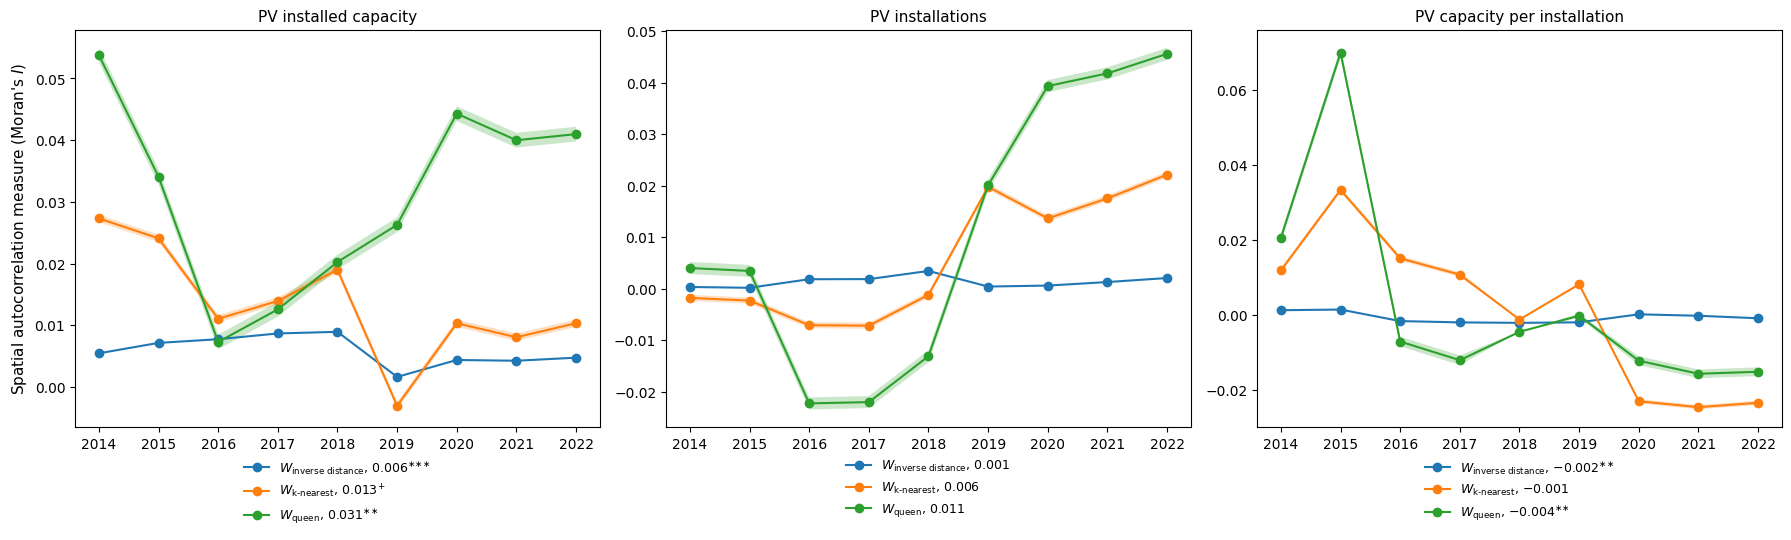

In [7]:
labels = {"log_pv_cap": "PV installed capacity",
        "log_pv_inst": "PV installations",
        "pv_cap_per_inst": "PV capacity per installation",
        
        "I_inverse_distance": r"$W_{\text{inverse distance}}$",
        "I_k_nearest": r"$W_{\text{k-nearest}}$",
        "I_queen": r"$W_{\text{queen}}$"}
methods = ['inverse_distance', 'k_nearest', 'queen']
fig = plt.figure(figsize=(6.0 * 3, 5.5))
ax_left = fig.add_subplot(1, 3, 1)
d = pv_cap_moran_results
for m in methods:
    i = d[['year'] + [i for i in d.columns if i.startswith(f'I_{m}')]].set_index('year')
    v = d[['year'] + [i for i in d.columns if i.startswith(f'VI_{m}')]].set_index('year')
    iv = average_morans_i(i, v)
    labels_ = {k: (f"{v}, ${iv['i_mean']:.3f}" + "^{" + f"{get_stars(iv['p-value'])}" + "}$").replace("*", r"{\ast}") for k, v in labels.items() if m in k}
    i = i.rename(columns=labels_)
    i.plot(ax=ax_left, marker='o',)
    ax_left.fill_between(i.index, i.iloc[:, 0] - v.iloc[:, 0], i.iloc[:, 0] + v.iloc[:, 0], alpha=0.25)
ax_left.set_title(labels['log_pv_cap'], fontsize=11)
ax_left.set_xlabel(None)
ax_left.set_ylabel("Spatial autocorrelation measure (Moran's $I$)", fontsize=11)
ax_left.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
               fontsize=9, frameon=False)

ax_middle = fig.add_subplot(1, 3, 2)
d = pv_inst_moran_results
for m in methods:
    i = d[['year'] + [i for i in d.columns if i.startswith(f'I_{m}')]].set_index('year')
    v = d[['year'] + [i for i in d.columns if i.startswith(f'VI_{m}')]].set_index('year')
    iv = average_morans_i(i, v)
    labels_ = {k: (f"{v}, ${iv['i_mean']:.3f}" + "^{" + f"{get_stars(iv['p-value'])}" + "}$").replace("*", r"{\ast}") for k, v in labels.items() if m in k}
    i = i.rename(columns=labels_)
    i.plot(ax=ax_middle, marker='o',)
    ax_middle.fill_between(i.index, i.iloc[:, 0] - v.iloc[:, 0], i.iloc[:, 0] + v.iloc[:, 0], alpha=0.25)
ax_middle.set_title(labels['log_pv_inst'], fontsize=11)
ax_middle.set_xlabel(None)
ax_middle.set_ylabel("", labelpad=-5)
ax_middle.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 fontsize=9, frameon=False)

ax_right = fig.add_subplot(1, 3, 3)
d = pv_cap_per_inst_moran_results
for m in methods:
    i = d[['year'] + [i for i in d.columns if i.startswith(f'I_{m}')]].set_index('year')
    v = d[['year'] + [i for i in d.columns if i.startswith(f'VI_{m}')]].set_index('year')
    iv = average_morans_i(i, v)
    labels_ = {k: (f"{v}, ${iv['i_mean']:.3f}" + "^{" + f"{get_stars(iv['p-value'])}" + "}$").replace("*", r"{\ast}") for k, v in labels.items() if m in k}
    i = i.rename(columns=labels_)
    i.plot(ax=ax_right, marker='o',)
    ax_right.fill_between(i.index, i.iloc[:, 0] - v.iloc[:, 0], i.iloc[:, 0] + v.iloc[:, 0], alpha=0.25)
ax_right.set_title(labels['pv_cap_per_inst'], fontsize=11)
ax_right.set_xlabel(None)
ax_right.set_ylabel("", labelpad=-5)
ax_right.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
                 fontsize=9, frameon=False)  

fig.subplots_adjust(wspace=0.001)
fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig_moran.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format="pdf",
    )

## Models

In [ ]:
#Income or Earnings
#Population or Households
#one from densities as they are correlated


In [8]:
df

,name,year,gdp,income,vad,gdp_cap,population,vad_tax,pv_cap,pv_inst,...,log_area,log_earnings,log_firms,log_population,log_house_price,log_irradiance,log_pv_cap_per_inst,log_fcapacity,log_hcapacity,log_acapacity
0,Aberdeen City,1998,5416,10258.0,5041,25113.0,NaN,224,NaN,NaN,...,4.268534,NaN,NaN,NaN,NaN,3.043448,NaN,NaN,NaN,NaN
25,Aberdeenshire,1998,3551,11875.0,3193,15698.0,NaN,235,NaN,NaN,...,5.800211,NaN,NaN,NaN,NaN,3.018676,NaN,NaN,NaN,NaN
50,Adur,1998,735,9319.0,628,12587.0,NaN,66,NaN,NaN,...,3.624064,NaN,NaN,NaN,4.841991,3.147503,NaN,NaN,NaN,NaN
75,Amber Valley,1998,1699,8870.0,1513,14881.0,NaN,107,NaN,NaN,...,4.423985,NaN,NaN,NaN,4.672107,3.074239,NaN,NaN,NaN,NaN
100,Angus,1998,1236,10909.0,1070,11255.0,NaN,107,NaN,NaN,...,5.338747,NaN,NaN,NaN,NaN,3.041786,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8924,Wrexham,2022,4323,NaN,3913,31928.0,135389.0,309,42.647,5147.0,...,4.702243,4.480754,3.486997,5.131587,NaN,3.069687,0.003584,0.009732,0.155297,0.012163
8949,Wychavon,2022,3900,NaN,3326,28985.0,134544.0,393,126.223,4287.0,...,4.821842,4.461784,3.916085,5.128868,NaN,3.090546,0.012602,0.025821,0.144007,0.004543
8974,Wyre,2022,2388,NaN,1980,20801.0,114924.0,305,20.064,1848.0,...,4.450508,4.487661,3.526210,5.060415,NaN,3.069103,0.004690,0.012508,0.147019,0.004291
8999,Wyre Forest,2022,1967,NaN,1591,19225.0,102306.0,299,8.282,1488.0,...,4.291023,4.472142,3.700790,5.009905,NaN,3.082804,0.002411,0.020804,0.156251,0.003582


In [12]:
models = {
    "ML_LagFE": ML_LagFE,
    "ML_LagRE": ML_LagRE,
    "ML_ErrorRE": ML_ErrorRE,
    "ML_ErrorFE": ML_ErrorFE,
    "PooledOLS": PooledOLS,
    "PanelFE": PanelFE,
    "PanelRE": PanelRE
}
w_methods = ['inverse_distance', 'k_nearest', 'queen']
y_vars = ['log_pv_cap', 'log_pv_inst', 'pv_cap_per_inst']
x_vars = {'densities': ['pdensity', 'hdensity', 'fdensity', 'adensity'],
          'capacities': ['log_gdp_cap', 'log_fcapacity', 'log_hcapacity', 'log_acapacity'],
          'baseline': ['log_income', 'log_hholds', 'log_irradiance'] # 'log_house_price', 
}

In [27]:
cache_weights = {}
weights_file = os.path.join(results_dir, 'cache_weights.pickle')
if os.path.exists(weights_file):
    with open(weights_file, 'rb') as f:
        cache_weights = pickle.load(f)

def get_cached_weights(y, x, w_method, f, df):
    if f in cache_weights:
        return cache_weights[f]
    else:
        w, X, Y = compute_weights(y, x, 
                                  data=df, 
                                  shape_data=la, 
                                  method=w_method, 
                                  verbose=False)
        cache_weights[f] = (w, X, Y)
        return w, X, Y

def compute_model(m_method, w_method, y, x, f, df):
    w, X, Y = get_cached_weights(y, x, w_method, f, df)
    if w is not None:
        model = None
        try:
            model = models[m_method](Y, X, w, name_y=y, name_x=x, name_w=w_method)
        except Exception as e:
            print(str(e))
        return model
    
model_results = {}
results_file = os.path.join(results_dir, 'model_results.pickle')
if os.path.exists(results_file):
    with open(results_file, 'rb') as f:
        model_results = pickle.load(f)
else:
    for y in y_vars:
        model_results.setdefault(y, {})
        for x_group, x_list in x_vars.items():
            model_results[y].setdefault(x_group, {})
            if x_group == "baseline":
                for m_name in models.keys():
                    model_results[y][x_group].setdefault(m_name, {})
                    for w_name in w_methods:
                        model_results[y][x_group][m_name].setdefault(w_name, {})
                        base_vars = x_vars['baseline'].copy()
                        if 'FE' in m_name:
                            base_vars.remove('log_irradiance')
                        f = f"Running {m_name}:{w_name} for {y} ~ ({x_group}): {base_vars}"
                        print(f)
                        model_results[y][x_group][m_name][w_name][f] = compute_model(m_name, w_name, y, base_vars, f, df)

            if x_group == "capacities":
                for m_name in models.keys():
                    model_results[y][x_group].setdefault(m_name, {})
                    for w_name in w_methods:
                        model_results[y][x_group][m_name].setdefault(w_name, {})
                        base_vars = x_vars['baseline'].copy()
                        if 'FE' in m_name:
                            base_vars.remove('log_irradiance')
                        f = f"Running {m_name}:{w_name} for {y} ~ ({x_group}): {x_vars['capacities']} + {base_vars}"
                        print(f)
                        model_results[y][x_group][m_name][w_name][f] = compute_model(m_name, w_name, y, x_vars['capacities'] + base_vars, f, df)

            if x_group == "densities":
                    for m_name in models.keys():
                        model_results[y][x_group].setdefault(m_name, {})
                        for w_name in w_methods:
                            model_results[y][x_group][m_name].setdefault(w_name, {}) 
                            base_vars = x_vars['baseline'].copy()
                            if 'FE' in m_name:
                                base_vars.remove('log_irradiance')
                            for x in x_list:
                                f = f"Running {m_name}:{w_name} for {y} ~ ({x_group}): {x} + {base_vars}"
                                print(f)
                                model_results[y][x_group][m_name][w_name][f] = compute_model(m_name, w_name, y, [x] + base_vars, f, df)
    with open(results_file, 'wb') as f:
        pickle.dump(model_results, f)

with open(weights_file, 'wb') as f:
        pickle.dump(cache_weights, f)

Running ML_LagFE:inverse_distance for log_pv_cap ~ (densities): pdensity + ['log_income', 'log_hholds']
ML_LagFE
Running ML_LagFE:inverse_distance for log_pv_cap ~ (densities): hdensity + ['log_income', 'log_hholds']
ML_LagFE
Running ML_LagFE:inverse_distance for log_pv_cap ~ (densities): fdensity + ['log_income', 'log_hholds']
ML_LagFE
Running ML_LagFE:inverse_distance for log_pv_cap ~ (densities): adensity + ['log_income', 'log_hholds']
ML_LagFE
Running ML_LagFE:k_nearest for log_pv_cap ~ (densities): pdensity + ['log_income', 'log_hholds']
ML_LagFE
Running ML_LagFE:k_nearest for log_pv_cap ~ (densities): hdensity + ['log_income', 'log_hholds']
ML_LagFE
Running ML_LagFE:k_nearest for log_pv_cap ~ (densities): fdensity + ['log_income', 'log_hholds']
ML_LagFE
Running ML_LagFE:k_nearest for log_pv_cap ~ (densities): adensity + ['log_income', 'log_hholds']
ML_LagFE
Running ML_LagFE:queen for log_pv_cap ~ (densities): pdensity + ['log_income', 'log_hholds']


c:\uktest\.venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 6 islands with ids: 43, 49, 312, 319, 321, 339.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\uktest\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 90 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\uktest\.venv\Lib\site-packages\libpysal\weights\util.py:761: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  return W(neighbors, weights, id_order=ids, **kwargs)


ML_LagFE
Running ML_LagFE:queen for log_pv_cap ~ (densities): hdensity + ['log_income', 'log_hholds']


c:\uktest\.venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 6 islands with ids: 43, 49, 312, 319, 321, 339.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\uktest\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 90 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\uktest\.venv\Lib\site-packages\libpysal\weights\util.py:761: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  return W(neighbors, weights, id_order=ids, **kwargs)


ML_LagFE
Running ML_LagFE:queen for log_pv_cap ~ (densities): fdensity + ['log_income', 'log_hholds']


...

Running PanelFE:queen for pv_cap_per_inst ~ (densities): fdensity + ['log_income', 'log_hholds']


c:\uktest\.venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 6 islands with ids: 43, 49, 312, 319, 321, 339.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\uktest\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 90 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Code E06000058 has only 6 unique years.
Code E06000059 has only 6 unique years.
Code E06000060 has only 4 unique years.
Code E06000061 has only 3 unique years.
Code E06000062 has only 3 unique years.
Code E07000112 has only 6 unique years.
Code E07000244 has only 6 unique years.
Code E07000245 has only 6 unique years.
Code N09000001 has only 3 unique years.
Code N09000002 has only 3 unique years.
Code N09000004 has only 3 unique years.
Code N09000005 has only 3 unique years.
Code N09000006 has only 3 unique years.
Code N09000007 has only 3 unique years.
Code N09000008 has only 3 unique years.
Code N09000009 has only 3 unique years.
Code N09000010 has only 3 unique years.
Code N09000011 has only 3 unique years.
Code S12000006 has only 3 unique years.
Code S12000013 has only 3 unique years.
Code S12000035 has only 3 unique years.
Code S12000036 has only 3 unique years.
Code S12000048 has only 3 unique years.
Code W06000014 has only 3 unique years.
Code W06000016 has only 3 unique years.


c:\uktest\.venv\Lib\site-packages\libpysal\weights\util.py:761: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There is 1 island with id: 285.
  return W(neighbors, weights, id_order=ids, **kwargs)


KeyboardInterrupt: 

In [25]:
df['pdensity'].describe()

count    4332.000000
mean       15.948577
std        23.897486
min         0.085353
25%         1.957650
50%         5.598683
75%        21.891742
max       163.802539
Name: pdensity, dtype: float64

In [26]:
#Running ML_ErrorRE:k_nearest for log_pv_cap ~ (densities): pdensity + ['log_income', 'log_hholds', 'log_irradiance']
y = 'log_pv_cap'
x = ['pdensity', 'log_income', 'log_hholds', 'log_irradiance', 
     #'pdensity', 
     #'hdensity', 
     #'fdensity', 
     #'adensity'

    #"log_gdp_cap",
    #"log_fcapacity",
    #"log_hcapacity",
    #"log_acapacity",

     ]
w_method = 'k_nearest'
w, X, Y = compute_weights(y, x, df, shape_data=la, method=w_method, verbose=True,)
model = ML_ErrorRE(Y, X, w=w, name_y=y, name_x=x, name_w=w_method, ftol=0)
print(model.summary)

Number of units: 354, Number of periods: 8 (2014-2021), Method: k_nearest


TypeError: ML_ErrorRE.__init__() got an unexpected keyword argument 'ftol'

In [ ]:
#Running ML_ErrorRE:k_nearest for log_pv_cap ~ (densities): pdensity + ['log_income', 'log_hholds', 'log_irradiance']
    

y = 'log_pv_cap'
x = ['log_income', 'log_hholds', 'log_house_price', 'log_irradiance', 
     #'pdensity', 
     #'hdensity', 
     #'fdensity', 
     #'adensity'

    #"log_gdp_cap",
    #"log_fcapacity",
    #"log_hcapacity",
    #"log_acapacity",

     ]
w_method = 'k_nearest'
w, X, Y = compute_weights(y, x, df, shape_data=la, method=w_method, verbose=True)
model = ML_ErrorFE(Y, X, w=w, name_y=y, name_x=x, name_w=w_method)
print(model.summary)

Number of units: 307, Number of periods: 8 (2014-2021), Method: inverse_distance
ML_ErrorFE
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR PANEL MODEL - FIXED EFFECTS
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :inverse_distance
Dependent Variable  :  log_pv_cap                Number of Observations:        2456
Mean dependent var  :     -0.0000                Number of Variables   :           4
S.D. dependent var  :      0.2230                Degrees of Freedom    :        2452
Pseudo R-squared    :      0.3778
Log likelihood      :   2505.6356
Sigma-square ML     :      0.0075                Akaike info criterion :   -5003.271
S.E of regression   :      0.0863                Schwarz criterion     :   -4980.046
Fixed-effects mean  :22383682419263.2383

------------------------------------------------------------------------------------
            Variable     Coe

In [46]:
df[df["irradiance"] >= 0]

,name,year,gdp,income,vad,gdp_cap,population,vad_tax,pv_cap,pv_inst,...,log_area,log_earnings,log_firms,log_population,log_house_price,log_irradiance,log_pv_cap_per_inst,log_fcapacity,log_hcapacity,log_acapacity
0,Aberdeen City,1998,5416,10258.0,5041,25113.0,NaN,224,NaN,NaN,...,4.268534,NaN,NaN,NaN,NaN,3.043448,NaN,NaN,NaN,NaN
25,Aberdeenshire,1998,3551,11875.0,3193,15698.0,NaN,235,NaN,NaN,...,5.800211,NaN,NaN,NaN,NaN,3.018676,NaN,NaN,NaN,NaN
50,Adur,1998,735,9319.0,628,12587.0,NaN,66,NaN,NaN,...,3.624064,NaN,NaN,NaN,4.841991,3.147503,NaN,NaN,NaN,NaN
75,Amber Valley,1998,1699,8870.0,1513,14881.0,NaN,107,NaN,NaN,...,4.423985,NaN,NaN,NaN,4.672107,3.074239,NaN,NaN,NaN,NaN
100,Angus,1998,1236,10909.0,1070,11255.0,NaN,107,NaN,NaN,...,5.338747,NaN,NaN,NaN,NaN,3.041786,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8924,Wrexham,2022,4323,NaN,3913,31928.0,135389.0,309,42.647,5147.0,...,4.702243,4.480754,3.486997,5.131587,NaN,3.069687,0.003584,0.009732,0.155297,0.012163
8949,Wychavon,2022,3900,NaN,3326,28985.0,134544.0,393,126.223,4287.0,...,4.821842,4.461784,3.916085,5.128868,NaN,3.090546,0.012602,0.025821,0.144007,0.004543
8974,Wyre,2022,2388,NaN,1980,20801.0,114924.0,305,20.064,1848.0,...,4.450508,4.487661,3.526210,5.060415,NaN,3.069103,0.004690,0.012508,0.147019,0.004291
8999,Wyre Forest,2022,1967,NaN,1591,19225.0,102306.0,299,8.282,1488.0,...,4.291023,4.472142,3.700790,5.009905,NaN,3.082804,0.002411,0.020804,0.156251,0.003582


In [11]:
y = 'log_pv_cap'
x = ['log_income', 'log_house_price', 'hholds_density', 'fdensity']
w_method = 'inverse_distance'
w, X, Y = compute_weights(y, x, df, method=w_method)
model = ML_LagFE(Y, X, w=w, name_y=y, name_x=x, name_w=w_method)
print(model.summary)

Number of units: 311, Number of periods: 8 (2014-2021)
ML_LagFE
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL LAG PANEL - FIXED EFFECTS
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :inverse_distance
Dependent Variable  :  log_pv_cap                Number of Observations:        2488
Mean dependent var  :     -0.0000                Number of Variables   :           5
S.D. dependent var  :      0.4780                Degrees of Freedom    :        2483
Pseudo R-squared    :      0.2723
Log likelihood      :  -1311.4918
Sigma-square ML     :      0.1664                Akaike info criterion :    2632.984
S.E of regression   :      0.4079                Schwarz criterion     :    2662.080
Fixed-effects mean  :      1.1858

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic   

In [276]:
y = 'log_pv_cap'
x = ['log_income', 'log_house_price', 'hholds_density']
w_method = 'queen'
w, X, Y = compute_weights(y, x, df, method=w_method)
model = ML_LagFE(Y, X, w=w, name_y=y, name_x=x, name_w=w_method)
print(model.summary)

c:\UK\.venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 6 islands with ids: 43, 49, 312, 319, 321, 339.
  W.__init__(self, neighbors, ids=ids, **kw)
c:\UK\.venv\Lib\site-packages\libpysal\weights\util.py:761: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
 There are 3 islands with ids: 41, 47, 289.
  return W(neighbors, weights, id_order=ids, **kwargs)


('WARNING: ', 43, ' is an island (no neighbors)')
('WARNING: ', 49, ' is an island (no neighbors)')
('WARNING: ', 312, ' is an island (no neighbors)')
('WARNING: ', 319, ' is an island (no neighbors)')
('WARNING: ', 321, ' is an island (no neighbors)')
('WARNING: ', 339, ' is an island (no neighbors)')
('WARNING: ', 41, ' is an island (no neighbors)')
('WARNING: ', 47, ' is an island (no neighbors)')
('WARNING: ', 289, ' is an island (no neighbors)')
Number of units: 311, Number of periods: 8 (2014-2021)
ML_LagFE
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL LAG PANEL - FIXED EFFECTS
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :       queen
Dependent Variable  :  log_pv_cap                Number of Observations:        2488
Mean dependent var  :     -0.0000                Number of Variables   :           4
S.D. dependent var  :      0.4780                Degrees of Fre

In [279]:
y = 'log_pv_cap'
x = ['log_income', 'log_house_price', 'hholds_density']
w_method = 'k_nearest'
k = 8
w, X, Y = compute_weights(y, x, df, method=w_method, k=k)
model = ML_LagFE(Y, X, w=w, name_y=y, name_x=x, name_w=f"{w_method}(k={k})")
print(model.summary)

Number of units: 311, Number of periods: 8 (2014-2021)
ML_LagFE
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL LAG PANEL - FIXED EFFECTS
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :k_nearest(k=8)
Dependent Variable  :  log_pv_cap                Number of Observations:        2488
Mean dependent var  :     -0.0000                Number of Variables   :           4
S.D. dependent var  :      0.4780                Degrees of Freedom    :        2484
Pseudo R-squared    :      0.3372
Log likelihood      :  -1226.7401
Sigma-square ML     :      0.1519                Akaike info criterion :    2461.480
S.E of regression   :      0.3898                Schwarz criterion     :    2484.757
Fixed-effects mean  :      0.6459

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     